# Geocalibration

Here we use the geocalibration data calculated from agisoft metashape using the OPK values. The fitting will be done for each focus positions and camera. We will use the $R^r_{r'}$ values fitted from the 034 and fit $R^m_{c,0}$ and $R^m_{c,1}$ for each left and right camera between focus positions 026-110.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import itertools
import plotly.express as px
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import os

from typing import List

In [70]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_mat = lambda x:np.array([[float(val.strip()) for val in r[1:].split(", ") if len(val)] for r in x[1:-2].split("], ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_comma)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_comma)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_comma)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_comma)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

  return z_data

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
    """
    Form the H matrix from the ground truth data
    """
    h_r = data_["h_r_vec"][idx]
    v_r = data_["v_r_vec"][idx]
    a_r = data_["a_r_vec"][idx]

    H_r = np.array([h_r, v_r, a_r]).T

    return H_r

# read in the data
data_fpath = "../plots/m41_site_cal_v230_v4_20240815_125829.xlsx"
data_all = pd.read_excel(data_fpath, index_col=0)
data_all = parse_cahvor(data_all)


In [71]:
data_all["cam"].unique()

array(['ZR063', 'ZR110', 'ZL110', 'ZL063', 'ZR048', 'ZR079', 'ZL048',
       'ZL079', 'ZR034', 'ZL034', 'ZL100', 'ZR100', 'ZR026', 'ZL026'],
      dtype=object)

In [72]:
f_str = "110"

zl_f = data_all[data_all["cam"]==f"ZL{f_str}"].copy().reset_index()
zr_f = data_all[data_all["cam"]==f"ZR{f_str}"].copy().reset_index()

fig = px.scatter(zl_f, x="fmc", y="f_est", hover_data=["index", "name"], title=f"ZL{f_str}")
fig.show()


fig = px.scatter(zr_f, x="fmc", y="f_est", hover_data=["index", "name"], title=f"ZR{f_str}")
fig.show()

In [73]:
l = [2530, 2527, 2536, 1712, 1710, 3246, 3244, 3245, 2108, 3249, 3222, 3247, 3248, 3228, 3242, 2279] +\
    [1312, 1327, 3092, 3091, 3090, 1705, 3095, 3068, 3093, 3094, 3074, 3088, 2140] +\
    [1001, 3232, 1002, 1005, 3099, 933, 1006, 981, 949, 1035, 3232, 961, 957, 3171, 953, 954, 956, 962, 1036, 1039, 1038, 1040, 1043, 1041, 1011] +\
    [636, 3078, 637, 638, 606, 2949, 640, 618, 646, 647, 645, 641, 550, 552, 567, 3003, 667, 673, 674, 668, 672, 671, 675, 645] +\
    [478, 289, 288, 290, 291, 293, 292, 296, 295, 297, 294, 477] +\
    [1, 0, 2, 4, 3, 5, 7, 6, 9, 190, 191] +\
    [3108, 3106, 3107, 3109, 3117] +\
    [2952, 2951, 2949, 2950, 931] +\
    [1706, 1992, 1774, 2005, 2079, 2937, 2939, 2929, 2946, 2079, 1791, 1790, 3184, 3169, 1993, 3164, 1971, 3158, 1963, 1975] +\
    [1557, 1560, 1573, 3025, 3067, 3066, 1548, 1306, 1301, 1297, 1299, 1305, 1307, 1298, 1304, 1300, 1302, 1560, 1567, 1598,1382] 
print(sorted(l))

[0, 1, 2, 3, 4, 5, 6, 7, 9, 190, 191, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 477, 478, 550, 552, 567, 606, 618, 636, 637, 638, 640, 641, 645, 645, 646, 647, 667, 668, 671, 672, 673, 674, 675, 931, 933, 949, 953, 954, 956, 957, 961, 962, 981, 1001, 1002, 1005, 1006, 1011, 1035, 1036, 1038, 1039, 1040, 1041, 1043, 1297, 1298, 1299, 1300, 1301, 1302, 1304, 1305, 1306, 1307, 1312, 1327, 1382, 1548, 1557, 1560, 1560, 1567, 1573, 1598, 1705, 1706, 1710, 1712, 1774, 1790, 1791, 1963, 1971, 1975, 1992, 1993, 2005, 2079, 2079, 2108, 2140, 2279, 2527, 2530, 2536, 2929, 2937, 2939, 2946, 2949, 2949, 2950, 2951, 2952, 3003, 3025, 3066, 3067, 3068, 3074, 3078, 3088, 3090, 3091, 3092, 3093, 3094, 3095, 3099, 3106, 3107, 3108, 3109, 3117, 3158, 3164, 3169, 3171, 3184, 3222, 3228, 3232, 3232, 3242, 3244, 3245, 3246, 3247, 3248, 3249]


In [74]:
# read in the data
data_all = pd.read_excel(data_fpath, index_col=0)
data_all = parse_cahvor(data_all)

# drop the outliers
drop_idxs = l
data_all.drop(axis=0, index=drop_idxs, inplace=True)
data_all.reset_index(inplace=True, drop=True)



# data structure to store the fits
f_strs = ['026', '034', '048', '063', '079', '110']
template = {"fl0":None, "fl1":None, 
          "rot_mc_0":None, "rot_mc_1":None,
          "lmbd_h":0.3, "lmbd_v":0.009, "lmbd_a":90}

params = {f"ZL{f_str}":template.copy() for f_str in f_strs}
params.update({f"ZR{f_str}":template.copy() for f_str in f_strs})
params["rot_rrp"] = R.from_quat([0,0,0,1])

# Focal Length Fits

In [75]:
for f_str in f_strs:
    # split zl and zr data
    zl, zr = get_zl_zr(f_str, data_all)

    # Left Camera fl-fmc fits 
    X_l, Y_l = np.vstack([np.ones(zl.shape[0]), zl["fmc"]]).T , zl["f_est"]
    theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
    params[f"ZL{f_str}"]["fl0"], params[f"ZL{f_str}"]["fl1"] = theta_l
    print(f"[ZL{f_str}] fl = {theta_l[0]:.5f} + {theta_l[1]:.5f} * fmc")

    # Right Camera fl-fmc fits 
    X_r, Y_r = np.vstack([np.ones(zr.shape[0]), zr["fmc"]]).T , zr["f_est"]
    theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
    params[f"ZR{f_str}"]["fl0"], params[f"ZR{f_str}"]["fl1"] = theta_r
    print(f"[ZR{f_str}] fl = {theta_r[0]:.5f} + {theta_r[1]:.5f} * fmc")

[ZL026] fl = 3654.06872 + 0.05132 * fmc
[ZR026] fl = 3615.92803 + 0.04713 * fmc
[ZL034] fl = 4691.07816 + 0.04152 * fmc
[ZR034] fl = 4697.04491 + 0.04395 * fmc
[ZL048] fl = 6588.41165 + 0.02861 * fmc
[ZR048] fl = 6572.73341 + 0.03509 * fmc
[ZL063] fl = 8522.91433 + 0.03329 * fmc
[ZR063] fl = 8293.17622 + 0.11351 * fmc
[ZL079] fl = 10678.78409 + 0.03735 * fmc
[ZR079] fl = 10281.29101 + 0.15527 * fmc
[ZL110] fl = 14412.20347 + 0.14049 * fmc
[ZR110] fl = 14674.87189 + 0.05871 * fmc


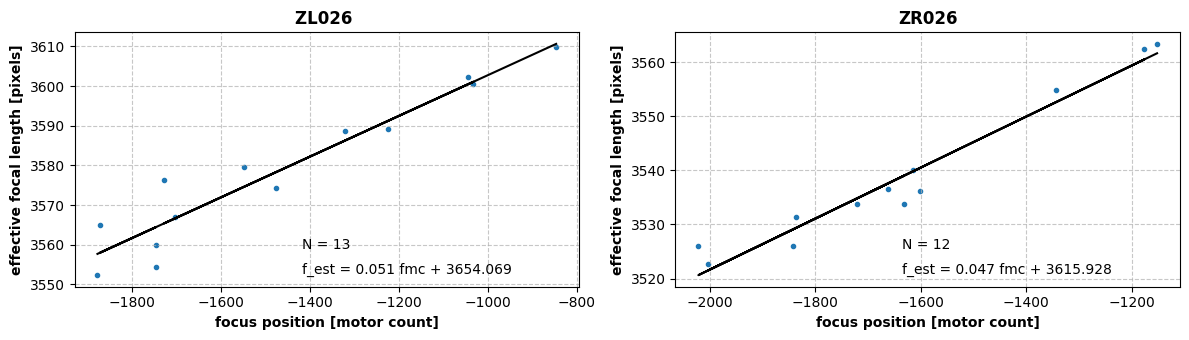

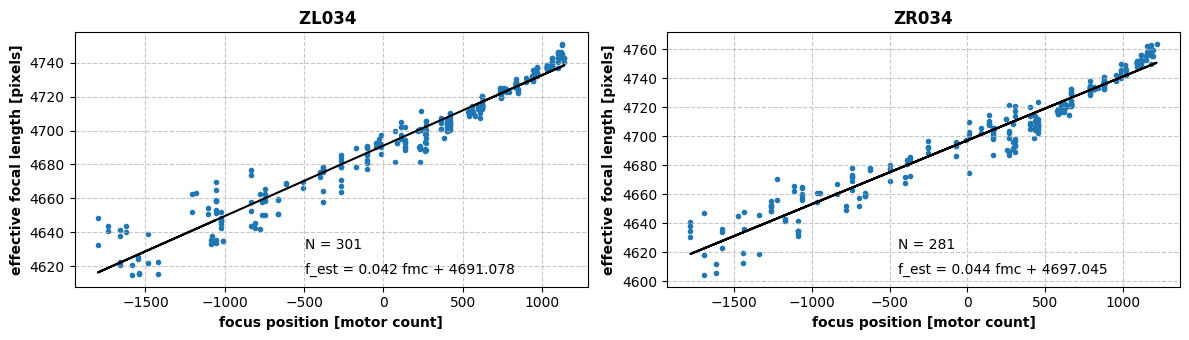

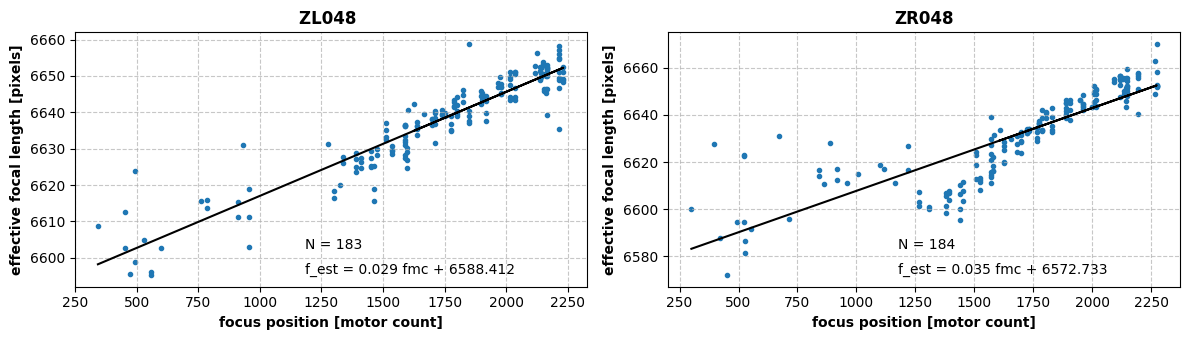

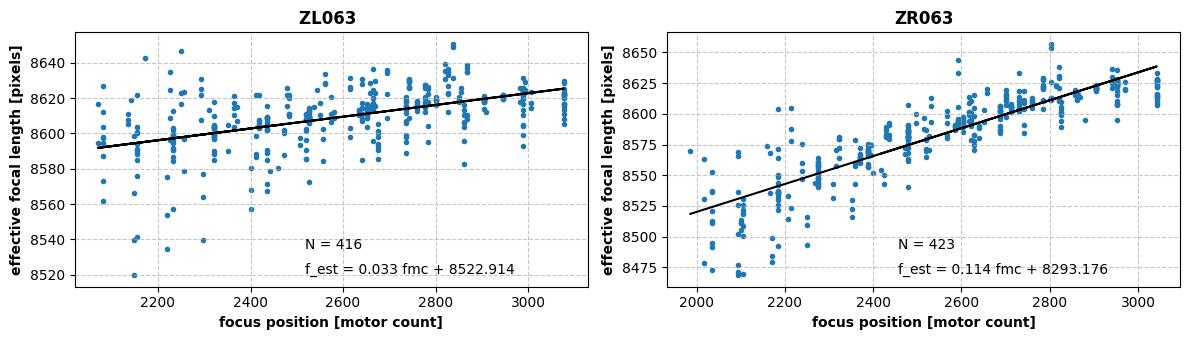

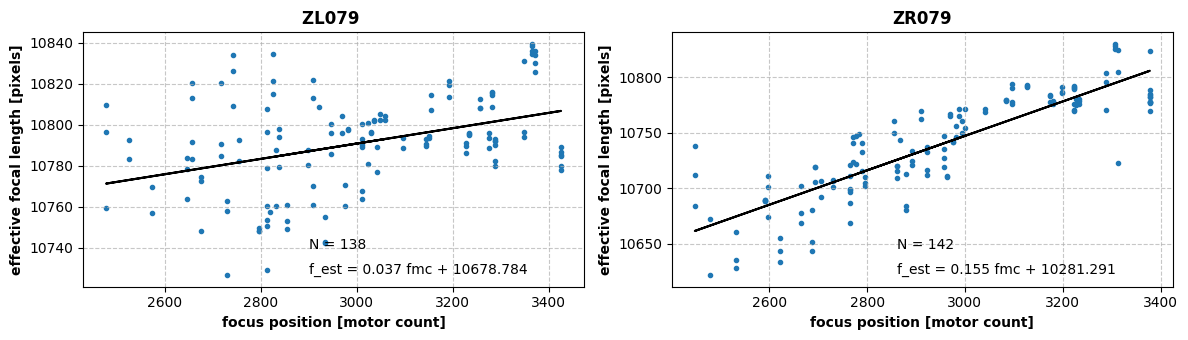

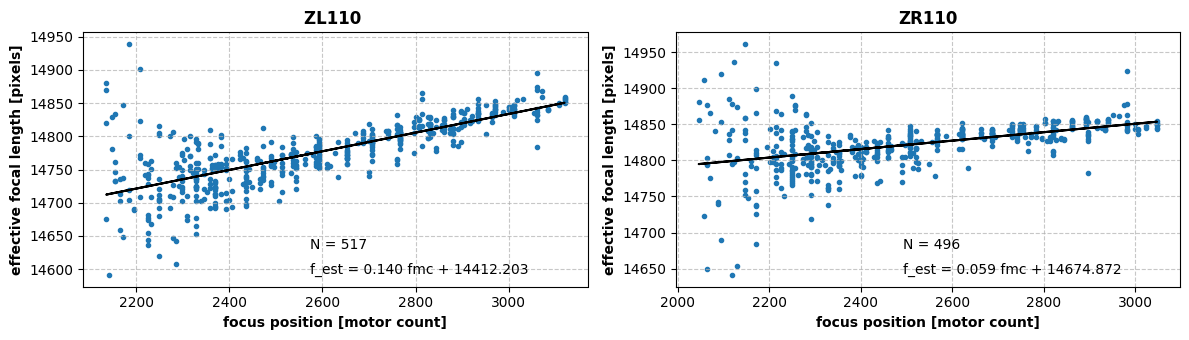

In [76]:
output_dir = "./results_v4"

for f_str in f_strs:
        fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))

        zl, zr = get_zl_zr(f_str, data_all)
        # ZL034 FL-FMC plots
        ax[0].scatter(zl["fmc"], zl["f_est"], marker='.')
        fl0_l, fl1_l = params[f"ZL{f_str}"]["fl0"], params[f"ZL{f_str}"]["fl1"]
        ax[0].plot(zl["fmc"], [fl0_l + fl1_l * f for f in zl["fmc"]],
                color="black")
        ax[0].grid(linestyle="--", alpha=0.7)
        ax[0].set_xlabel("focus position [motor count]", fontweight="bold")
        ax[0].set_ylabel("effective focal length [pixels]", fontweight="bold")
        ax[0].set_title(f"ZL{f_str} ", fontweight="bold")
        ax[0].text(0.45, 0.05, "f_est = {:.3f} fmc + {:.3f}".format(fl1_l, fl0_l), transform=ax[0].transAxes)
        ax[0].text(0.45, 0.15, f"N = {zl.shape[0]}", transform=ax[0].transAxes)



        # ZR034 FL-FMC plots
        ax[1].scatter(zr["fmc"], zr["f_est"], marker='.')
        fl0_r, fl1_r = params[f"ZR{f_str}"]["fl0"], params[f"ZR{f_str}"]["fl1"]
        ax[1].plot(zr["fmc"], [fl0_r + fl1_r * f for f in zr["fmc"]],
                color="black")
        ax[1].grid(linestyle="--", alpha=0.7)
        ax[1].set_xlabel("focus position [motor count]", fontweight="bold")
        ax[1].set_ylabel("effective focal length [pixels]", fontweight="bold")
        ax[1].set_title(f"ZR{f_str}", fontweight="bold")
        ax[1].text(0.45, 0.05, "f_est = {:.3f} fmc + {:.3f}".format(fl1_r, fl0_r), transform=ax[1].transAxes)
        ax[1].text(0.45, 0.15, f"N = {zr.shape[0]}", transform=ax[1].transAxes)


        fig.tight_layout()

        fig.savefig(os.path.join(output_dir, f"ZLZR{f_str}_FL_FMC.png"), format='png')

# Rotation Fitting

### Kabsch Fit

In [77]:

def solve_r_mc(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()
    R_rrp = params_["rot_rrp"].as_matrix()

    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # LEFT CAMERA FITS
        m_frame_l, c_frame_l = [], []
        for i in range(zl.shape[0]):
            # compute hm from hr
            Hr = get_H_r_data(i, zl)
            R_rpm = get_R_rpm(i, zl)
            Hm = (R_rrp @ R_rpm).T @ Hr
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_h"] * Hm[:, 0])
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_v"] * Hm[:, 1])
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_a"] * Hm[:, 2])

            # compute hc
            f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i, :]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_h"] * Hc[:, 0])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_v"] * Hc[:, 1])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_a"] * Hc[:, 2])

        params_[f"ZL{f_str}"]["rot_mc_0"], _ = R.align_vectors(m_frame_l, c_frame_l, return_sensitivity=False)

        # RIGHT CAMERA FITS
        m_frame_r, c_frame_r = [], []
        for i in range(zr.shape[0]):
            # compute hm from hr
            Hr = get_H_r_data(i, zr)
            R_rpm = get_R_rpm(i, zr)
            Hm = (R_rrp @ R_rpm).T @ Hr
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_h"] * Hm[:, 0])
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_v"] * Hm[:, 1])
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_a"] * Hm[:, 2])

            # compute hc
            f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i, :]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_h"] * Hc[:, 0])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_v"] * Hc[:, 1])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_a"] * Hc[:, 2])

        params_[f"ZR{f_str}"]["rot_mc_0"], _ = R.align_vectors(m_frame_r, c_frame_r, return_sensitivity=False)
    
    return params_

def solve_r_rrp(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()
    # solve for rrp
    r_frame, rp_frame = [], []

    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_all)

        # left camera
        R_mc_l = params_[f"ZL{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zl.shape[0]):
            # r frame vectors
            Hr = get_H_r_data(i, zl)
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_h"] * Hr[:, 0])
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_v"] * Hr[:, 1])
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_a"] * Hr[:, 2])

            # r' frame vectors
            R_rpm = get_R_rpm(i, zl)
            f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hrp = R_rpm @ R_mc_l @ Hc
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_h"] * Hrp[:, 0])
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_v"] * Hrp[:, 1])
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_a"] * Hrp[:, 2])

        # right camera
        R_mc_r = params_[f"ZR{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zr.shape[0]):
            # r frame vectors
            Hr = get_H_r_data(i, zr)
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_h"] * Hr[:, 0])
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_v"] * Hr[:, 1])
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_a"] * Hr[:, 2])

            # r' frame vectors
            R_rpm = get_R_rpm(i, zr)
            f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hrp = R_rpm @ R_mc_l @ Hc
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_h"] * Hrp[:, 0])
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_v"] * Hrp[:, 1])
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_a"] * Hrp[:, 2])

    params_["rot_rrp"], _ = R.align_vectors(r_frame, rp_frame, return_sensitivity=False)
    return params_
    
def calc_total_rel_error(data_, params_):
    # compute the relative error
    data_ = data_.copy()
    params_ = params_.copy()

    R_rrp = params["rot_rrp"].as_matrix()
    tot_rel_err = 0
    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # left camera errors
        R_mc_l = params_[f"ZL{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zl.shape[0]):
            Hr_data = get_H_r_data(i, zl)

            R_rpm = get_R_rpm(i, zl)
            f, b1, b2, cx, cy = zl[["fmc", "b1", "b2", "cx", "cy"]].iloc[i, :]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hr_model = R_rrp @ R_rpm @ R_mc_l @ Hc

            tot_rel_err = np.linalg.norm(Hr_data[:, 0] - Hr_model[:, 0])/np.linalg.norm(Hr_data[:, 0])
            tot_rel_err = np.linalg.norm(Hr_data[:, 1] - Hr_model[:, 1])/np.linalg.norm(Hr_data[:, 1])
            tot_rel_err = np.linalg.norm(Hr_data[:, 2] - Hr_model[:, 2])/np.linalg.norm(Hr_data[:, 2])


        # right camera errors
        R_mc_r = params_[f"ZR{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zr.shape[0]):
            Hr_data = get_H_r_data(i, zr)

            R_rpm = get_R_rpm(i, zr)
            f, b1, b2, cx, cy = zr[["fmc", "b1", "b2", "cx", "cy"]].iloc[i, :]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hr_model = R_rrp @ R_rpm @ R_mc_r @ Hc

            tot_rel_err = np.linalg.norm(Hr_data[:, 0] - Hr_model[:, 0])/np.linalg.norm(Hr_data[:, 0])
            tot_rel_err = np.linalg.norm(Hr_data[:, 1] - Hr_model[:, 1])/np.linalg.norm(Hr_data[:, 1])
            tot_rel_err = np.linalg.norm(Hr_data[:, 2] - Hr_model[:, 2])/np.linalg.norm(Hr_data[:, 2])
    
    return tot_rel_err

def kabsch_fit(data_, params_, verbosity=False, niters=250, verbose=25, eps=1e-6):
    data_ = data_.copy()
    params_ = params_.copy()

    total_rel_err = 0
    for i in range(niters):
        params_ = solve_r_mc(data_, params_)
        params_ = solve_r_rrp(data_, params_)
        total_rel_err_new = calc_total_rel_error(data_, params)

        # if change in relative error is small, break the loop
        if abs(total_rel_err - total_rel_err_new) < eps:
            if verbosity:
                print(f"Iteration {i}")
                print(f"Total Relative Error: {total_rel_err:.8f}")
                for f_str in f_strs:
                    print(f"[ZL{f_str}] q_mc: {params_[f'ZL{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                    print(f"[ZR{f_str}] q_mc: {params_[f'ZR{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                print(f"q_rrp: {params_['rot_rrp'].as_quat(canonical=True)}")
            break
        total_rel_err = total_rel_err_new

        # print for verbosity
        if verbosity and ((i%verbose == 0 and i>0) or (i == niters-1)):
            print(f"Iteration {i}")
            print(f"Total Relative Error: {total_rel_err:.8f}")
            for f_str in f_strs:
                print(f"[ZL{f_str}] q_mc: {params_[f'ZL{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                print(f"[ZR{f_str}] q_mc: {params_[f'ZR{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
            print(f"q_rrp: {params_['rot_rrp'].as_quat(canonical=True)}")
            print("="*150)

    return params_


In [78]:
params = kabsch_fit(data_all, params, verbosity=True, niters=500)

Text(0.5, 0.98, '$H^r$ for ZL034 Iterative Kabsch Fit')

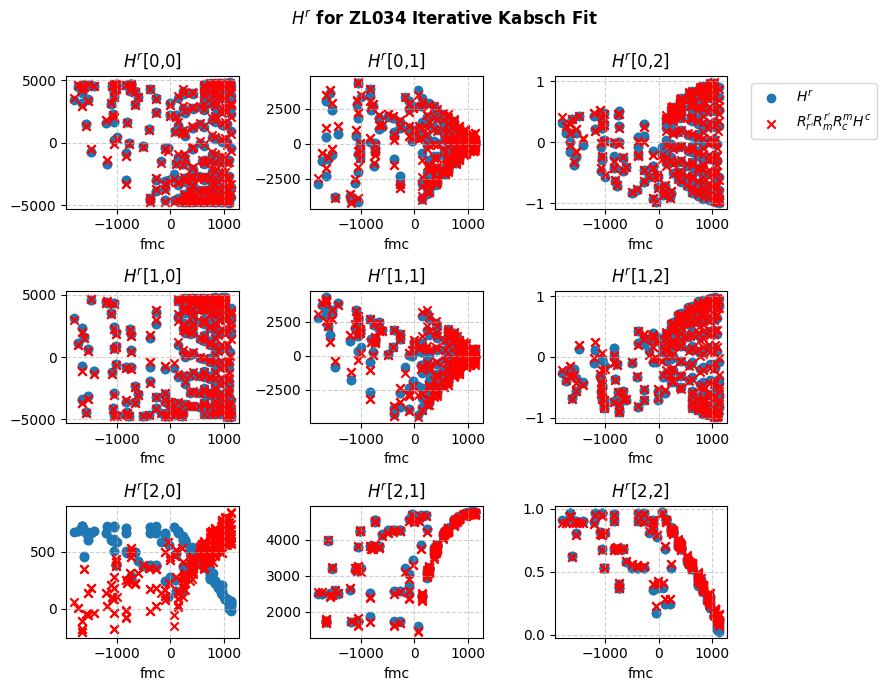

In [9]:
def plot_hr(data_, rot_rrp, rot_mc, fl0, fl1):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ plot", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

zl34 = data_all[data_all["cam"]=="ZL034"].reset_index(drop=True)
fig, ax = plot_hr(zl34, rot_rrp=params["rot_rrp"], rot_mc=params["ZL034"]["rot_mc_0"],
              fl0=params["ZL034"]["fl0"], fl1=params["ZL034"]["fl1"])
fig.suptitle("$H^r$ for ZL034 Iterative Kabsch Fit", fontweight="bold", fontsize=12)

Text(0.5, 0.98, '$H^r$ for ZL034 Iterative Kabsch Fit')

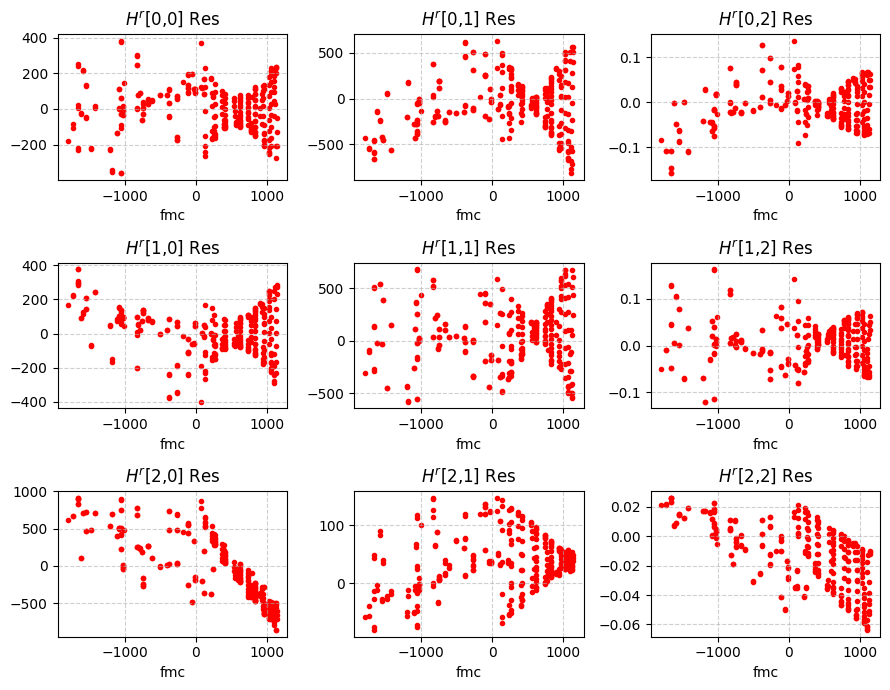

In [10]:
def plot_hr_res(data_, rot_rrp, rot_mc, fl0, fl1):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.tight_layout()

  return fig, ax

plot_hr_res(zl34, rot_rrp=params["rot_rrp"], rot_mc=params["ZL034"]["rot_mc_0"],
              fl0=params["ZL034"]["fl0"], fl1=params["ZL034"]["fl1"])
fig.suptitle("$H^r$ for ZL034 Iterative Kabsch Fit", fontweight="bold", fontsize=12)

Next, we use the rotations that were found by the iterative kabsch algorithm as an initial guess for BFGS fits. 

In [ ]:
def obj(x):
    # objective function value
    R_rrp = R.from_quat(x[:4]).as_matrix()

    total_cost = 0
    for i, f_str in enumerate(f_strs):
        strt_idx = 4 + i * 16
        rot_mc_l_0 = R.from_quat(x[strt_idx : strt_idx+4])
        rot_mc_l_1 = R.from_quat(x[strt_idx+4 : strt_idx+8])
        rot_mc_r_0 = R.from_quat(x[strt_idx+8 : strt_idx+12])
        rot_mc_r_1 = R.from_quat(x[strt_idx+12 : strt_idx+16])

        zl, zr = get_zl_zr(f_str, data_all)

        # left camera
        for i in range(zl.shape[0]):
            # H^r matrix
            Hr = get_H_r_data(i, zl)

            # H^c matrix
            f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            cam = zl["cam"].iloc[i]
            fl = params[f"ZL{f_str}"]["fl0"] + params[f"ZL{f_str}"]["fl1"] * f
            Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

            # rotation matrices
            R_rpm = get_R_rpm(i, zl)
            R_mc = (rot_mc_l_0 * (rot_mc_l_1**(f/1000))).as_matrix()

            # Errors
            err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
            total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
            total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
            total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2

        # right camera
        for i in range(zr.shape[0]):
            # H^r matrix
            Hr = get_H_r_data(i, zr)

            # H^c matrix
            f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            cam = zr["cam"].iloc[i]
            fl = params[f"ZR{f_str}"]["fl0"] + params[f"ZR{f_str}"]["fl1"] * f
            Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

            # rotation matrices
            R_rpm = get_R_rpm(i, zr)
            R_mc = (rot_mc_r_0 * (rot_mc_r_1**(f/1000))).as_matrix()

            # Errors
            err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
            total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
            total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
            total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2        

    return total_cost

# initial values for BFGS
x0 = list(params["rot_rrp"].as_quat(canonical=True))
for f_str in f_strs:
    x0 += list(params[f"ZL{f_str}"]["rot_mc_0"].as_quat(canonical=True))
    x0 += [0,0,0,1]
    x0 += list(params[f"ZR{f_str}"]["rot_mc_0"].as_quat(canonical=True))
    x0 += [0,0,0,1]

# Run BFGS algoithm
res = minimize(obj, x0, method="BFGS",
        options={"gtol":1e-6, "xrtol":1e-6, "maxiter":1000})

# print results
print(f"q_rrp: {list(res.x[:4])}")
for i, f_str in enumerate(f_strs):
    strt_idx =  4 + i * 16

    print(f"[ZL{f_str}] q_mc_0: {list(res.x[strt_idx:strt_idx+4])}")
    print(f"[ZL{f_str}] q_mc_1: {list(res.x[strt_idx+4:strt_idx+8])}")
    print(f"[ZR{f_str}] q_mc_0: {list(res.x[strt_idx+8:strt_idx+12])}")
    print(f"[ZR{f_str}] q_mc_1: {list(res.x[strt_idx+12:strt_idx+16])}")

q_rrp: [-0.00010227755857568948, -8.84544395044508e-05, 0.0011397706562578192, 0.9810802130041153]
[ZL026] q_mc_0: [0.4410504992844332, 0.4509118726749375, 0.453374316246655, 0.4466000296663345]
[ZL026] q_mc_1: [-0.0002830590899366945, -7.822248228651495e-05, 0.0006838415787315055, 0.9769245946193965]
[ZR026] q_mc_0: [0.4793811655468466, 0.4652386930248482, 0.47323529892017274, 0.4824354279012532]
[ZR026] q_mc_1: [-0.0004753237818916833, -2.9784093417085382e-05, 1.8431985449310624e-05, 0.9051794942425624]
[ZL034] q_mc_0: [0.48533726243611885, 0.49874761611220453, 0.499579034117871, 0.492134392483303]
[ZL034] q_mc_1: [9.135016462727654e-05, -0.0001564555064252598, 4.5408936893289894e-05, 0.8763457485748217]
[ZR034] q_mc_0: [0.4970921285508994, 0.481843602878304, 0.48993922736743056, 0.5004895428007207]
[ZR034] q_mc_1: [0.00011509890032137313, -0.00020942343636957053, 5.6565325439450336e-05, 0.9190158453279452]
[ZL048] q_mc_0: [0.46256383477385776, 0.4795320783303101, 0.4768431616164752,

In [ ]:
# here we compute the relative errors of our fits
def compute_err_hr(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
    rot_mc_0 = R.from_quat(q_mc_0)
    rot_mc_1 = R.from_quat(q_mc_1)
    R_rrp = R.from_quat(q_rrp).as_matrix()

    h_abs_err_all, h_rel_err_all = [], []
    v_abs_err_all, v_rel_err_all = [], []
    a_abs_err_all, a_rel_err_all = [], []

    for i in range(data_.shape[0]):
        # compute Hr from data
        Hr_data = get_H_r_data(i, data_)

        # compute Hr from model
        f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
        cam = data_["cam"].iloc[i]
        fl = fl0 + fl1 * f
        Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
        R_rpm = get_R_rpm(i, data_)
        f = data_["fmc"][i]
        rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
        R_mc = rot_mc.as_matrix()
        Hr_model = R_rrp @ R_rpm @ R_mc @ Hc

        # compute erros and store them
        h_abs_err = np.linalg.norm(Hr_data[:,0] - Hr_model[:,0])
        h_rel_err = h_abs_err / np.linalg.norm(Hr_data[:,0])
        h_abs_err_all.append(h_abs_err)
        h_rel_err_all.append(h_rel_err)

        v_abs_err = np.linalg.norm(Hr_data[:,1] - Hr_model[:,1])
        v_rel_err = v_abs_err / np.linalg.norm(Hr_data[:,1])
        v_abs_err_all.append(v_abs_err)
        v_rel_err_all.append(v_rel_err)

        a_abs_err = np.linalg.norm(Hr_data[:,2] - Hr_model[:,2])
        a_rel_err = a_abs_err / np.linalg.norm(Hr_data[:,2])
        a_abs_err_all.append(a_abs_err)
        a_rel_err_all.append(a_rel_err)

    h_abs_err_mean, h_abs_err_std = np.mean(h_abs_err_all), np.std(h_abs_err_all)
    h_rel_err_mean, h_rel_err_std = np.mean(h_rel_err_all), np.std(h_rel_err_all)
    
    v_abs_err_mean, v_abs_err_std = np.mean(v_abs_err_all), np.std(v_abs_err_all)
    v_rel_err_mean, v_rel_err_std = np.mean(v_rel_err_all), np.std(v_rel_err_all)

    a_abs_err_mean, a_abs_err_std = np.mean(a_abs_err_all), np.std(a_abs_err_all)
    a_rel_err_mean, a_rel_err_std = np.mean(a_rel_err_all), np.std(a_rel_err_all)

    return h_abs_err_mean, h_abs_err_std, h_rel_err_mean, h_rel_err_std, \
            v_abs_err_mean, v_abs_err_std, v_rel_err_mean, v_rel_err_std, \
            a_abs_err_mean, a_abs_err_std, a_rel_err_mean, a_rel_err_std,  


In [ ]:
# here we save the parameters to a JSON file
temps = {"fl0":None, "fl1":None, "q_mc_0":None, "q_mc_1":None,
         "t_mc_0":[0,0,0], "t_mc_1":[0,0,0],
         "cx_est":None, "cy_est":None, "b1_est":None, "b2_est":None, "N":None}
params_save = {f"ZL{f_str}":temps.copy() for f_str in f_strs}
params_save.update({f"ZR{f_str}":temps.copy() for f_str in f_strs})
params_save["q_rrp"] = list(R.from_quat(res.x[:4]).as_quat(canonical=True))
params_save["t_rrp"] = [0, 0, 0]

for i, f_str in enumerate(f_strs):

    zl, zr = get_zl_zr(f_str, data_all)
    
    strt_idx =  4 + i * 16
    params_save[f"ZL{f_str}"]["fl0"], params_save[f"ZL{f_str}"]["fl1"] = params[f"ZL{f_str}"]["fl0"], params[f"ZL{f_str}"]["fl1"]  
    params_save[f"ZL{f_str}"]["q_mc_0"] = list(R.from_quat(res.x[strt_idx:strt_idx+4]).as_quat(canonical=True))
    params_save[f"ZL{f_str}"]["q_mc_1"] = list(R.from_quat(res.x[strt_idx+4:strt_idx+8]).as_quat(canonical=True))
    params_save[f"ZL{f_str}"]["cx_est"] = float(zl["cx_est"][0])
    params_save[f"ZL{f_str}"]["cy_est"] = float(zl["cy_est"][0])
    params_save[f"ZL{f_str}"]["b1_est"] = float(zl["b1_est"][0])
    params_save[f"ZL{f_str}"]["b2_est"] = float(zl["b2_est"][0])
    params_save[f"ZL{f_str}"]["N"] = zl.shape[0]

    h_abs_err_mean, h_abs_err_std, h_rel_err_mean, h_rel_err_std, \
    v_abs_err_mean, v_abs_err_std, v_rel_err_mean, v_rel_err_std, \
    a_abs_err_mean, a_abs_err_std, a_rel_err_mean, a_rel_err_std, = \
        compute_err_hr(zl, q_rrp=res.x[:4], q_mc_0=res.x[strt_idx:strt_idx+4], q_mc_1=res.x[strt_idx+4:strt_idx+8],
                        fl0=params[f"ZL{f_str}"]["fl0"], fl1=params[f"ZL{f_str}"]["fl1"])
    params_save[f"ZL{f_str}"]["h_abs_err_mean"] = h_abs_err_mean
    params_save[f"ZL{f_str}"]["h_abs_err_std"] = h_abs_err_std
    params_save[f"ZL{f_str}"]["h_rel_err_mean"] = h_rel_err_mean
    params_save[f"ZL{f_str}"]["h_rel_err_std"] = h_rel_err_std

    params_save[f"ZL{f_str}"]["v_abs_err_mean"] = v_abs_err_mean
    params_save[f"ZL{f_str}"]["v_abs_err_std"] = v_abs_err_std
    params_save[f"ZL{f_str}"]["v_rel_err_mean"] = v_rel_err_mean
    params_save[f"ZL{f_str}"]["v_rel_err_std"] = v_rel_err_std

    params_save[f"ZL{f_str}"]["a_abs_err_mean"] = a_abs_err_mean
    params_save[f"ZL{f_str}"]["a_abs_err_std"] = a_abs_err_std
    params_save[f"ZL{f_str}"]["a_rel_err_mean"] = a_rel_err_mean
    params_save[f"ZL{f_str}"]["a_rel_err_std"] = a_rel_err_std

    
    params_save[f"ZR{f_str}"]["fl0"], params_save[f"ZR{f_str}"]["fl1"] = params[f"ZR{f_str}"]["fl0"], params[f"ZR{f_str}"]["fl1"]  
    params_save[f"ZR{f_str}"]["q_mc_0"] = list(R.from_quat(res.x[strt_idx+8:strt_idx+12]).as_quat(canonical=True))
    params_save[f"ZR{f_str}"]["q_mc_1"] = list(R.from_quat(res.x[strt_idx+12:strt_idx+16]).as_quat(canonical=True))
    params_save[f"ZR{f_str}"]["cx_est"] = float(zr["cx_est"][0])
    params_save[f"ZR{f_str}"]["cy_est"] = float(zr["cy_est"][0])
    params_save[f"ZR{f_str}"]["b1_est"] = float(zr["b1_est"][0])
    params_save[f"ZR{f_str}"]["b2_est"] = float(zr["b2_est"][0])
    params_save[f"ZR{f_str}"]["N"] = zr.shape[0]

    h_abs_err_mean, h_abs_err_std, h_rel_err_mean, h_rel_err_std, \
    v_abs_err_mean, v_abs_err_std, v_rel_err_mean, v_rel_err_std, \
    a_abs_err_mean, a_abs_err_std, a_rel_err_mean, a_rel_err_std, = \
        compute_err_hr(zr, q_rrp=res.x[:4], q_mc_0=res.x[strt_idx+8:strt_idx+12], q_mc_1=res.x[strt_idx+12:strt_idx+16],
                        fl0=params[f"ZR{f_str}"]["fl0"], fl1=params[f"ZR{f_str}"]["fl1"])
    params_save[f"ZR{f_str}"]["h_abs_err_mean"] = h_abs_err_mean
    params_save[f"ZR{f_str}"]["h_abs_err_std"] = h_abs_err_std
    params_save[f"ZR{f_str}"]["h_rel_err_mean"] = h_rel_err_mean
    params_save[f"ZR{f_str}"]["h_rel_err_std"] = h_rel_err_std

    params_save[f"ZR{f_str}"]["v_abs_err_mean"] = v_abs_err_mean
    params_save[f"ZR{f_str}"]["v_abs_err_std"] = v_abs_err_std
    params_save[f"ZR{f_str}"]["v_rel_err_mean"] = v_rel_err_mean
    params_save[f"ZR{f_str}"]["v_rel_err_std"] = v_rel_err_std

    params_save[f"ZR{f_str}"]["a_abs_err_mean"] = a_abs_err_mean
    params_save[f"ZR{f_str}"]["a_abs_err_std"] = a_abs_err_std
    params_save[f"ZR{f_str}"]["a_rel_err_mean"] = a_rel_err_mean
    params_save[f"ZR{f_str}"]["a_rel_err_std"] = a_rel_err_std

with open("Fits_v230_v4.json", 'w+') as f:
    json.dump(params_save, f, indent=3)

params = params_save

In [ ]:
def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_qmc_hr_err(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_err = []


  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    Hr_model = R_rrp @ R_rpm @ R_mc @ Hc

    hr_err.append(Hr_data - Hr_model)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_err], 
                      marker=".", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ Errors {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_qmc_hm(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hm_data, hm_model = [], []
  for i in range(data_.shape[0]):
    # compute Hr from "data"
    Hr = get_H_r_data(i, data_)
    R_rpm = get_R_rpm(i, data_)
    hm_data.append((R_rrp @ R_rpm).T @ Hr)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()
    hm_model.append(R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hm_data],
                      label="$(R^r_{r'} R^{r'}_m)^T H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hm_model], 
                      marker="x", color="red",
                      label="$R^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^m$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^m$ {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax


f_str = "034"
zl = data_all[data_all["cam"]==f"ZL{f_str}"].reset_index(drop=True)
zr = data_all[data_all["cam"]==f"ZR{f_str}"].reset_index(drop=True)

fig, ax = plot_qmc_hr(zl, q_rrp=params["q_rrp"], 
              q_mc_0 = params[f"ZL{f_str}"]["q_mc_0"], q_mc_1 = params[f"ZL{f_str}"]["q_mc_1"],
              fl0=params[f"ZL{f_str}"]["fl0"], fl1=params[f"ZL{f_str}"]["fl1"])

fig, ax = plot_qmc_hr(zr, q_rrp=params["q_rrp"], 
              q_mc_0 = params[f"ZR{f_str}"]["q_mc_0"], q_mc_1 = params[f"ZR{f_str}"]["q_mc_1"],
              fl0=params[f"ZR{f_str}"]["fl0"], fl1=params[f"ZR{f_str}"]["fl1"])

fig, ax = plot_qmc_hr_err(zl, q_rrp=params["q_rrp"], 
              q_mc_0 = params[f"ZL{f_str}"]["q_mc_0"], q_mc_1 = params[f"ZL{f_str}"]["q_mc_1"],
              fl0=params[f"ZL{f_str}"]["fl0"], fl1=params[f"ZL{f_str}"]["fl1"])

fig, ax = plot_qmc_hr_err(zr, q_rrp=params["q_rrp"], 
              q_mc_0 = params[f"ZR{f_str}"]["q_mc_0"], q_mc_1 = params[f"ZR{f_str}"]["q_mc_1"],
              fl0=params[f"ZR{f_str}"]["fl0"], fl1=params[f"ZR{f_str}"]["fl1"])

In [ ]:
fig_op_dir = "./results_v4"

f_str = "026"
zl = data_all[data_all["cam"]==f"ZL{f_str}"].reset_index(drop=True)
zr = data_all[data_all["cam"]==f"ZR{f_str}"].reset_index(drop=True)

fig, ax = plot_qmc_hm(zl, q_rrp=params["q_rrp"], q_mc_0=params["ZL034"]["q_mc_0"], q_mc_1=params["ZL034"]["q_mc_1"],
            fl0=params["ZL034"]["fl0"], fl1 = params["ZL034"]["fl1"])
# fig.savefig(os.path.join(fig_op_dir, f"ZL{f_str}_Hm_v230_v3.png"), format="png")

fig, ax = plot_qmc_hm(zr, q_rrp=params["q_rrp"], q_mc_0=params["ZR034"]["q_mc_0"], q_mc_1=params["ZR034"]["q_mc_1"],
            fl0=params["ZR034"]["fl0"], fl1 = params["ZR034"]["fl1"])
# fig.savefig(os.path.join(fig_op_dir, f"ZR{f_str}_Hm_v230_v3.png"), format="png")

## Translation Fitting

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import itertools
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

from typing import List

In [118]:
# Load the data
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_mat = lambda x:np.array([[float(val.strip()) for val in r[1:].split(", ") if len(val)] for r in x[1:-2].split("], ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_comma)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_comma)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_comma)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_comma)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

  return z_data

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
    """
    Form the H matrix from the ground truth data
    """
    h_r = data_["h_r_vec"][idx]
    v_r = data_["v_r_vec"][idx]
    a_r = data_["a_r_vec"][idx]

    H_r = np.array([h_r, v_r, a_r]).T

    return H_r


data_fpath = "../plots/m41_site_cal_v230_v4_20240815_125829.xlsx"
params_fpath = "./Fits_v4.json"
f_strs = ["026", "034", "048", "063", "079", "110"]

# read in the data
data_all = pd.read_excel(data_fpath, index_col=0)
data_all = parse_cahvor(data_all)

# drop the outliers
drop_idxs = [0, 1, 2, 3, 4, 5, 6, 7, 9, 190, 191, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 477, 478, 550, 552, 567, 606, 618, 636, 637, 638, 640, 641, 645, 645, 646, 647, 667, 668, 671, 672, 673, 674, 675, 931, 933, 949, 953, 954, 956, 957, 961, 962, 981, 1001, 1002, 1005, 1006, 1011, 1035, 1036, 1038, 1039, 1040, 1041, 1043, 1297, 1298, 1299, 1300, 1301, 1302, 1304, 1305, 1306, 1307, 1312, 1327, 1382, 1548, 1557, 1560, 1560, 1567, 1573, 1598, 1705, 1706, 1710, 1712, 1774, 1790, 1791, 1963, 1971, 1975, 1992, 1993, 2005, 2079, 2079, 2108, 2140, 2279, 2527, 2530, 2536, 2929, 2937, 2939, 2946, 2949, 2949, 2950, 2951, 2952, 3003, 3025, 3066, 3067, 3068, 3074, 3078, 3088, 3090, 3091, 3092, 3093, 3094, 3095, 3099, 3106, 3107, 3108, 3109, 3117, 3158, 3164, 3169, 3171, 3184, 3222, 3228, 3232, 3232, 3242, 3244, 3245, 3246, 3247, 3248, 3249]
data_all.drop(axis=0, index=drop_idxs, inplace=True)
data_all.reset_index(inplace=True, drop=True)

# Load the parameters
with open(params_fpath, 'r') as f:
    params = json.load(f)

In [119]:
# here we assume the value of t_rrp and solve for t_mc
def solve_t_mc(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()

    # parse the rotations and translations
    t_rrp = params_["t_rrp"]
    R_rrp = R.from_quat(params_["q_rrp"]).as_matrix()

    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # left camera
        t_mc_l = np.array([0, 0, 0])
        for i in range(zl.shape[0]):
            R_rpm = np.array(zl["R_rpm_mat"][i])
            t_rpm = np.array(zl["t_rpm_vec"][i])
            c_r = np.array(zl["c_r_vec"][i])

            t_mc_l = t_mc_l + (R_rrp @ R_rpm).T @ (c_r - R_rrp @ t_rpm - t_rrp)
            
        params_[f"ZL{f_str}"]["t_mc_0"] =  list(t_mc_l/zl.shape[0])

        # right camera
        t_mc_r = np.array([0, 0, 0])
        for i in range(zr.shape[0]):            
            R_rpm = np.array(zr["R_rpm_mat"][i])
            t_rpm = np.array(zr["t_rpm_vec"][i])
            c_r = np.array(zr["c_r_vec"][i])

            t_mc_r = t_mc_r + (R_rrp @ R_rpm).T @ (c_r - R_rrp @ t_rpm - t_rrp)
            
        params_[f"ZR{f_str}"]["t_mc_0"] =  list(t_mc_r/zr.shape[0])

    return params_

def solve_t_rrp(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()

    t_rrp = np.array([0, 0, 0])
    count = 0
    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # parse the rotations and translations
        t_mc_l = params_[f"ZL{f_str}"]["t_mc_0"]
        t_mc_r = params_[f"ZR{f_str}"]["t_mc_0"]
        R_rrp = R.from_quat(params_["q_rrp"]).as_matrix()

        # left camera
        for i in range(zl.shape[0]):
            R_rpm = np.array(zl["R_rpm_mat"][i])
            t_rpm = np.array(zl["t_rpm_vec"][i])
            c_r = np.array(zl["c_r_vec"][i])    
            t_rrp = t_rrp + (c_r - R_rrp @ t_rpm - R_rrp @ R_rpm @ t_mc_l)
            count += 1

        # right camera
        for i in range(zr.shape[0]):
            R_rpm = np.array(zr["R_rpm_mat"][i])
            t_rpm = np.array(zr["t_rpm_vec"][i])
            c_r = np.array(zr["c_r_vec"][i])
            t_rrp = t_rrp + (c_r - R_rrp @ t_rpm - R_rrp @ R_rpm @ t_mc_r)
            count += 1
            
    params_["t_rrp"] = t_rrp / count
    return params_

def calc_t_err(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()

    # parse the rotations and translations
    R_rrp = R.from_quat(params_["q_rrp"]).as_matrix()
    t_rrp = np.array(params_["t_rrp"])
    
    errs = 0
    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # left camera
        t_mc_l = np.array(params_[f"ZL{f_str}"]["t_mc_0"])
        for i in range(zl.shape[0]):
            R_rpm = np.array(zl["R_rpm_mat"][i])
            t_rpm = np.array(zl["t_rpm_vec"][i])
            c_r = np.array(zl["c_r_vec"][i])    
            
            errs += np.linalg.norm(c_r - R_rrp @ t_rpm - R_rrp @ R_rpm @ t_mc_l - t_rrp)**2

        # right camera
        t_mc_r = np.array(params_[f"ZR{f_str}"]["t_mc_0"])
        for i in range(zr.shape[0]):
            R_rpm = np.array(zr["R_rpm_mat"][i])
            t_rpm = np.array(zr["t_rpm_vec"][i])
            c_r = np.array(zr["c_r_vec"][i])
            errs += np.linalg.norm(c_r - R_rrp @ t_rpm - R_rrp @ R_rpm @ t_mc_r - t_rrp)**2
    
    return errs

t_rrp:			[ 0.00150397 -0.0016029   0.00210036]
[ZL026] t_mc_0_l:	[0.043592898285363106, -0.12434895248641202, -0.06689391222202874]
[ZR026] t_mc_0_r:	[0.048041594057444396, 0.1189180464359331, -0.06628871751553937]
[ZL034] t_mc_0_l:	[0.03119826465983888, -0.1241621496833388, -0.06746891902810154]
[ZR034] t_mc_0_r:	[0.03453520550910647, 0.11896225722470499, -0.06749995722881647]
[ZL048] t_mc_0_l:	[0.012875039174477456, -0.12391891436362994, -0.06854561281480084]
[ZR048] t_mc_0_r:	[0.018646514811555808, 0.11973889070350625, -0.06840950937704135]
[ZL063] t_mc_0_l:	[0.0028206392580800983, -0.12364405577990205, -0.06712948215078486]
[ZR063] t_mc_0_r:	[0.009450211338609632, 0.11849527657628366, -0.0667914677398833]
[ZL079] t_mc_0_l:	[0.0016905878374083568, -0.12456575776173369, -0.06808644633718468]
[ZR079] t_mc_0_r:	[0.007597555517031498, 0.11915536242766869, -0.06789349950721776]
[ZL110] t_mc_0_l:	[0.020020815373472663, -0.12346024204264597, -0.06861507310019149]
[ZR110] t_mc_0_r:	[0.02242

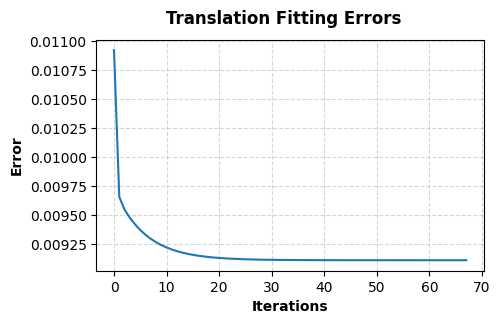

In [120]:
niters = 100
eps = 1e-9

errs = []
for i in range(niters):
    params = solve_t_mc(data_all, params)
    params = solve_t_rrp(data_all, params)

    err_i = calc_t_err(data_all, params)
    if len(errs) and (errs[-1] - err_i) < eps:
        break 
    errs.append(err_i)

print(f"t_rrp:\t\t\t{params['t_rrp']}")
for f_str in f_strs:
    print(f"[ZL{f_str}] t_mc_0_l:\t{params[f'ZL{f_str}']['t_mc_0']}")
    print(f"[ZR{f_str}] t_mc_0_r:\t{params[f'ZR{f_str}']['t_mc_0']}")

fig, ax = plt.subplots(1, 1, figsize=(5,3))
ax.plot(errs)
ax.grid(linestyle='--', alpha=0.5)
ax.set_xlabel("Iterations", fontweight="bold")
ax.set_ylabel("Error", fontweight="bold")
fig.suptitle("Translation Fitting Errors", fontsize=12, fontweight="bold");

In [121]:
# here we perform a BFGS fit
def obj(x):
    # parse the rotations and translations
    R_rrp = R.from_quat(params["q_rrp"]).as_matrix()
    t_rrp = np.array(x[:3])

    errs = 0
    for idx, f_str in enumerate(f_strs):
        strt_idx = 3 + idx * 12
        t_mc_0_l, t_mc_1_l = np.array(x[strt_idx:strt_idx+3]), np.array(x[strt_idx+3:strt_idx+6])
        t_mc_0_r, t_mc_1_r = np.array(x[strt_idx+6:strt_idx+9]), np.array(x[strt_idx+9:strt_idx+12])
        zl, zr = get_zl_zr(f_str, data_all)

        # left camera
        for i in range(zl.shape[0]):
            f = zl["fmc"][i]
            t_mc_l = t_mc_0_l + f * t_mc_1_l
            R_rpm = np.array(zl["R_rpm_mat"][i])
            t_rpm = np.array(zl["t_rpm_vec"][i])
            c_r = np.array(zl["c_r_vec"][i])    
            
            errs += np.linalg.norm(c_r - R_rrp @ t_rpm - R_rrp @ R_rpm @ t_mc_l - t_rrp)**2

        # right camera
        for i in range(zr.shape[0]):
            f = zr["fmc"][i]
            t_mc_r = t_mc_0_r + f * t_mc_1_r
            R_rpm = np.array(zr["R_rpm_mat"][i])
            t_rpm = np.array(zr["t_rpm_vec"][i])
            c_r = np.array(zr["c_r_vec"][i])
            errs += np.linalg.norm(c_r - R_rrp @ t_rpm - R_rrp @ R_rpm @ t_mc_r - t_rrp)**2

    return errs

# initial values for BFGS
x0 = list(params["t_rrp"])
for f_str in f_strs:
    x0 += list(params[f"ZL{f_str}"]["t_mc_0"])
    x0 += [0,0,0]
    x0 += list(params[f"ZR{f_str}"]["t_mc_0"])
    x0 += [0,0,0]

res = minimize(obj, x0, method="BFGS", 
        options={"gtol":1e-9, "xrtol":1e-9, "maxiter":5000})

In [124]:
def compute_err_cr(data_, q_rrp, t_rrp, t_mc_0, t_mc_1):

    R_rrp = R.from_quat(q_rrp).as_matrix()
    t_rrp = params["t_rrp"]

    c_abs_err, c_rel_err = [], []
    # left camera
    for i in range(data_.shape[0]):
        c_r_data = np.array(data_["c_r_vec"][i])

        f = data_["fmc"][i]
        t_mc = np.array(t_mc_0) + f * np.array(t_mc_1)
        R_rpm = np.array(data_["R_rpm_mat"][i])
        t_rpm = np.array(data_["t_rpm_vec"][i])
        c_r_model = R_rrp @ R_rpm @ t_mc + R_rrp @ t_rpm + t_rrp

        c_abs_err.append(np.linalg.norm(c_r_data - c_r_model))
        c_rel_err.append(np.linalg.norm(c_r_data - c_r_model)/np.linalg.norm(c_r_data))
    
    return np.mean(c_abs_err), np.std(c_abs_err), np.mean(c_rel_err), np.std(c_abs_err)

In [125]:
params["t_rrp"] = list(res.x[:3])
print(f"t_rrp: {res.x[:3]}")
for idx, f_str in enumerate(f_strs):
    strt_idx = 3 + idx * 12

    zl, zr = get_zl_zr(f_str, data_all)
    # left camera
    t_mc_0_l, t_mc_1_l = res.x[strt_idx:strt_idx+3], res.x[strt_idx+3:strt_idx+6]
    params[f"ZL{f_str}"]["t_mc_0"] = list(t_mc_0_l)
    params[f"ZL{f_str}"]["t_mc_1"] = list(t_mc_1_l)
    mu_c_abs, std_c_abs, mu_c_rel, std_c_rel = compute_err_cr(zl, params["q_rrp"], params["t_rrp"], list(t_mc_0_l), list(t_mc_1_l))
    params[f"ZL{f_str}"]["c_abs_err_mean"] = mu_c_abs
    params[f"ZL{f_str}"]["c_abs_err_std"] = std_c_abs
    params[f"ZL{f_str}"]["c_rel_err_mean"] = mu_c_rel
    params[f"ZL{f_str}"]["c_rel_err_std"] = std_c_rel
    

    # right camera
    t_mc_0_r, t_mc_1_r = res.x[strt_idx+6:strt_idx+9], res.x[strt_idx+9:strt_idx+12]
    params[f"ZR{f_str}"]["t_mc_0"] = list(t_mc_0_r)
    params[f"ZR{f_str}"]["t_mc_1"] = list(t_mc_1_r)
    mu_c_abs, std_c_abs, mu_c_rel, std_c_rel = compute_err_cr(zr, params["q_rrp"], params["t_rrp"], list(t_mc_0_r), list(t_mc_1_r))
    params[f"ZR{f_str}"]["c_abs_err_mean"] = mu_c_abs
    params[f"ZR{f_str}"]["c_abs_err_std"] = std_c_abs
    params[f"ZR{f_str}"]["c_rel_err_mean"] = mu_c_rel
    params[f"ZR{f_str}"]["c_rel_err_std"] = std_c_rel

    print(f"[ZL{f_str}] t_mc_0: {t_mc_0_l}")
    print(f"[ZL{f_str}] t_mc_1: {t_mc_1_l}")
    print(f"[ZR{f_str}] t_mc_0: {t_mc_0_r}")
    print(f"[ZR{f_str}] t_mc_1: {t_mc_1_r}")


with open("Fits_v3_2.json", "w+") as f:
    json.dump(params, f, indent=3)

t_rrp: [ 0.00150397 -0.0016029   0.00210036]
[ZL026] t_mc_0: [ 0.0435929  -0.12434895 -0.06689391]
[ZL026] t_mc_1: [ 3.40225958e-08  1.44339720e-08 -1.22890367e-07]
[ZR026] t_mc_0: [ 0.04804159  0.11891805 -0.06628872]
[ZR026] t_mc_1: [-1.02445608e-07 -4.18909426e-08 -1.59414504e-07]
[ZL034] t_mc_0: [ 0.03119827 -0.12416215 -0.06746892]
[ZL034] t_mc_1: [-7.84804412e-07  1.07510411e-07 -5.91979512e-07]
[ZR034] t_mc_0: [ 0.0345352   0.11896226 -0.06749996]
[ZR034] t_mc_1: [ 7.55021005e-07  3.15222006e-07 -4.59293299e-07]
[ZL048] t_mc_0: [ 0.01287504 -0.12391891 -0.06854561]
[ZL048] t_mc_1: [-1.42549379e-07 -2.13646164e-08 -3.80030058e-08]
[ZR048] t_mc_0: [ 0.01864652  0.11973889 -0.06840951]
[ZR048] t_mc_1: [-4.21586290e-08 -1.72340271e-08 -4.01845726e-08]
[ZL063] t_mc_0: [ 0.00282064 -0.12364405 -0.06712948]
[ZL063] t_mc_1: [-6.15365454e-09 -1.74698643e-08 -2.46455822e-09]
[ZR063] t_mc_0: [ 0.00945021  0.11849528 -0.06679147]
[ZR063] t_mc_1: [-4.23404617e-09 -2.94601739e-09 -3.08265307e

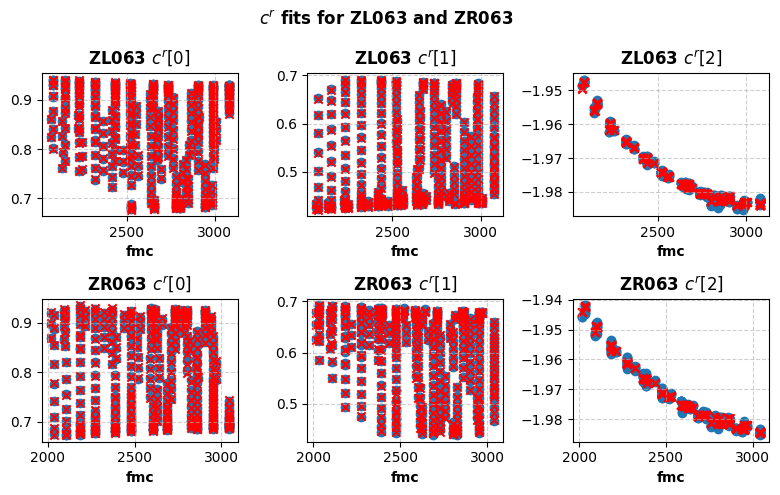

In [128]:
f_str = "063"

zl, zr = get_zl_zr(f_str, data_all)
# plots for c_r fits
R_rrp = R.from_quat(params["q_rrp"]).as_matrix()
t_rrp = params["t_rrp"]
t_mc_0_l, t_mc_1_l = np.array(params[f"ZL{f_str}"]["t_mc_0"]), np.array(params[f"ZL{f_str}"]["t_mc_1"])
t_mc_0_r, t_mc_1_r = np.array(params[f"ZR{f_str}"]["t_mc_0"]), np.array(params[f"ZR{f_str}"]["t_mc_1"])

left_cr_data, left_cr_model, right_cr_data, right_cr_model = [], [], [], []
left_abs_err, left_rel_err, right_abs_err, right_rel_err = [], [], [], []
left_cr_err, right_cr_err = [], []
# left camera
for i in range(zl.shape[0]):
    c_r_data = np.array(zl["c_r_vec"][i])
    left_cr_data.append(c_r_data)   

    f = zl["fmc"][i]
    t_mc_l = t_mc_0_l + f * t_mc_1_l
    R_rpm = np.array(zl["R_rpm_mat"][i])
    t_rpm = np.array(zl["t_rpm_vec"][i])
    c_r_model = R_rrp @ R_rpm @ t_mc_l + R_rrp @ t_rpm + t_rrp
    left_cr_model.append(c_r_model)

    left_cr_err.append(c_r_data - c_r_model)
    left_abs_err.append(np.linalg.norm( c_r_data - c_r_model ))
    left_rel_err.append(np.linalg.norm( c_r_data - c_r_model ) / np.linalg.norm(c_r_data))

# right camera
for i in range(zr.shape[0]):
    c_r_data = np.array(zr["c_r_vec"][i])
    right_cr_data.append(c_r_data)   

    f = zr["fmc"][i]
    t_mc_r = t_mc_0_r + f * t_mc_1_r
    R_rpm = np.array(zr["R_rpm_mat"][i])
    t_rpm = np.array(zr["t_rpm_vec"][i])
    c_r_model = R_rrp @ R_rpm @ t_mc_r + R_rrp @ t_rpm + t_rrp
    right_cr_model.append(c_r_model)

    right_cr_err.append(c_r_data - c_r_model)
    right_abs_err.append(np.linalg.norm( c_r_data - c_r_model ))
    right_rel_err.append(np.linalg.norm( c_r_data - c_r_model ) / np.linalg.norm(c_r_data))

fig, ax = plt.subplots(2, 3, figsize=(8, 5))
# left camera plots
for i in range(3):
    ax[0, i].scatter(zl["fmc"], [d[i] for d in left_cr_data], )
    ax[0, i].scatter(zl["fmc"], [d[i] for d in left_cr_model], marker='x', color='red')
    ax[0, i].set_xlabel("fmc", fontweight="bold")
    ax[0, i].set_title(f"ZL{f_str} $c^r[{i}]$", fontweight="bold")
    ax[0, i].grid(linestyle="--", alpha=0.6)

# right camera plots
for i in range(3):
    ax[1, i].scatter(zr["fmc"], [d[i] for d in right_cr_data], )
    ax[1, i].scatter(zr["fmc"], [d[i] for d in right_cr_model], marker='x', color='red')
    ax[1, i].set_xlabel("fmc", fontweight="bold")
    ax[1, i].set_title(f"ZR{f_str} $c^r[{i}]$", fontweight="bold")
    ax[1, i].grid(linestyle="--", alpha=0.6)

fig.suptitle(f"$c^r$ fits for ZL{f_str} and ZR{f_str}", fontweight="bold", fontsize=12)
fig.tight_layout()

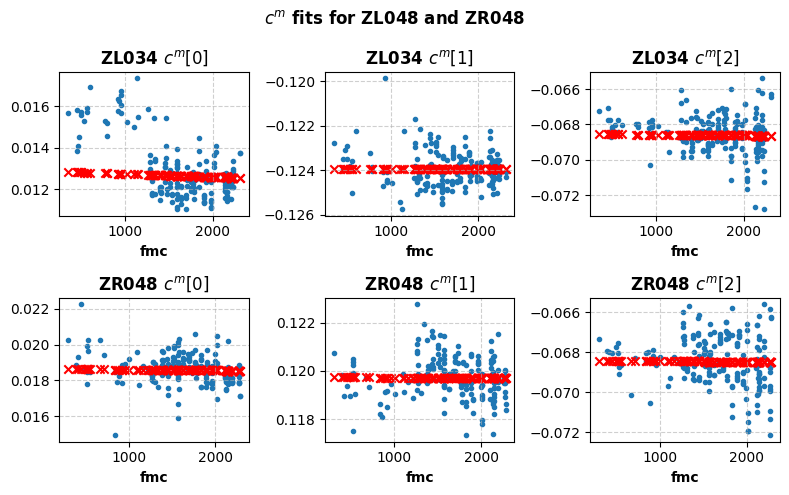

In [130]:
f_str = "048"

zl, zr = get_zl_zr(f_str, data_all)
R_rrp = R.from_quat(params["q_rrp"]).as_matrix()
t_rrp = params["t_rrp"]
t_mc_0_l, t_mc_1_l = np.array(params[f"ZL{f_str}"]["t_mc_0"]), np.array(params[f"ZL{f_str}"]["t_mc_1"])
t_mc_0_r, t_mc_1_r = np.array(params[f"ZR{f_str}"]["t_mc_0"]), np.array(params[f"ZR{f_str}"]["t_mc_1"])

left_cm_data, left_cm_model, right_cm_data, right_cm_model = [], [], [], []
left_cm_err, right_cm_err = [], []
# left camera
for i in range(zl.shape[0]):

    # c_m from "data"    
    c_r = np.array(zl["c_r_vec"][i])
    R_rpm = np.array(zl["R_rpm_mat"][i])
    t_rpm = np.array(zl["t_rpm_vec"][i])
    left_cm_data.append(R_rpm.T @ R_rrp.T @ c_r - R_rpm.T @ R_rrp.T @ t_rrp - R_rpm.T @ t_rpm)

    # c_m from mofrl
    f = zl["fmc"][i]
    t_mc_l = t_mc_0_l + f * t_mc_1_l
    left_cm_model.append(t_mc_l)

# right camera
for i in range(zr.shape[0]):

    # c_m from "data"    
    c_r = np.array(zr["c_r_vec"][i])
    R_rpm = np.array(zr["R_rpm_mat"][i])
    t_rpm = np.array(zr["t_rpm_vec"][i])
    right_cm_data.append(R_rpm.T @ R_rrp.T @ c_r - R_rpm.T @ R_rrp.T @ t_rrp - R_rpm.T @ t_rpm)

    # c_m from mofrl
    f = zr["fmc"][i]
    t_mc_r = t_mc_0_r + f * t_mc_1_r
    right_cm_model.append(t_mc_r)

fig, ax = plt.subplots(2, 3, figsize=(8, 5))
# left camera plots
for i in range(3):
    ax[0, i].scatter(zl["fmc"], [d[i] for d in left_cm_data], marker='.')
    ax[0, i].scatter(zl["fmc"], [d[i] for d in left_cm_model], marker='x', color='red')
    ax[0, i].set_xlabel("fmc", fontweight="bold")
    ax[0, i].set_title(f"ZL034 $c^m[{i}]$", fontweight="bold")
    ax[0, i].grid(linestyle="--", alpha=0.6)

# right camera plots
for i in range(3):
    ax[1, i].scatter(zr["fmc"], [d[i] for d in right_cm_data], marker='.')
    ax[1, i].scatter(zr["fmc"], [d[i] for d in right_cm_model], marker='x', color='red')
    ax[1, i].set_xlabel("fmc", fontweight="bold")
    ax[1, i].set_title(f"ZR{f_str} $c^m[{i}]$", fontweight="bold")
    ax[1, i].grid(linestyle="--", alpha=0.6)

fig.suptitle(f"$c^m$ fits for ZL{f_str} and ZR{f_str}", fontweight="bold", fontsize=12)
fig.tight_layout()